<a href="https://colab.research.google.com/github/Vandit2006/music-instrument-recognition/blob/main/Ml_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries for audio processing and ML
!pip install librosa soundfile scikit-learn numpy pandas matplotlib tqdm

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdulvahap/music-instrunment-sounds-for-classification")

print("Path to dataset files:", path)

100%|██████████| 4.59G/4.59G [00:57<00:00, 86.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abdulvahap/music-instrunment-sounds-for-classification/versions/1


In [3]:
!pip install kaggle

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vanditparmar11","key":"3ed364b2bd816ea3dd2864dd7f89fd5e"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d abdulvahap/music-instrunment-sounds-for-classification

Dataset URL: https://www.kaggle.com/datasets/abdulvahap/music-instrunment-sounds-for-classification
License(s): apache-2.0
100% 4.59G/4.59G [00:31<00:00, 157MB/s]



In [7]:
!unzip music-instrunment-sounds-for-classification.zip -d dataset/

Streaming output truncated to the last 5000 lines.
  inflating: dataset/music_dataset/Violin/53.wav  
  inflating: dataset/music_dataset/Violin/530.wav  
  inflating: dataset/music_dataset/Violin/531.wav  
  inflating: dataset/music_dataset/Violin/532.wav  
  inflating: dataset/music_dataset/Violin/533.wav  
  inflating: dataset/music_dataset/Violin/534.wav  
  inflating: dataset/music_dataset/Violin/535.wav  
  inflating: dataset/music_dataset/Violin/536.wav  
  inflating: dataset/music_dataset/Violin/537.wav  
  inflating: dataset/music_dataset/Violin/538.wav  
  inflating: dataset/music_dataset/Violin/539.wav  
  inflating: dataset/music_dataset/Violin/54.wav  
  inflating: dataset/music_dataset/Violin/540.wav  
  inflating: dataset/music_dataset/Violin/541.wav  
  inflating: dataset/music_dataset/Violin/542.wav  
  inflating: dataset/music_dataset/Violin/543.wav  
  inflating: dataset/music_dataset/Violin/544.wav  
  inflating: dataset/music_dataset/Violin/545.wav  
  inflating: da

In [8]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root, len(files))

dataset 0
dataset/music_dataset 0
dataset/music_dataset/Dobro 487
dataset/music_dataset/flute 3719
dataset/music_dataset/Saxophone 454
dataset/music_dataset/Horn 1258
dataset/music_dataset/Violin 630
dataset/music_dataset/Bass_Guitar 3613
dataset/music_dataset/Shakers 1357
dataset/music_dataset/Piano 575
dataset/music_dataset/Ukulele 790
dataset/music_dataset/Accordion 3581
dataset/music_dataset/Acoustic_Guitar 3654
dataset/music_dataset/Harmonium 1314
dataset/music_dataset/Harmonica 131
dataset/music_dataset/Drum_set 3648
dataset/music_dataset/Organ 1442
dataset/music_dataset/Tambourine 558
dataset/music_dataset/Banjo 2998
dataset/music_dataset/Floor_Tom 406
dataset/music_dataset/Clarinet 634
dataset/music_dataset/vibraphone 506
dataset/music_dataset/Electro_Guitar 1316
dataset/music_dataset/Mandolin 2458
dataset/music_dataset/Keyboard 2041
dataset/music_dataset/Hi_Hats 444
dataset/music_dataset/Cymbals 208
dataset/music_dataset/Trombone 2965
dataset/music_dataset/Trumpet 503
dataset/

In [9]:
import librosa
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

In [10]:
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=22050, duration=5.0, mono=True)

        # MFCC
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)
        mfcc_mean = np.mean(mfcc.T, axis=0)

        # Chroma
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)

        # Spectral Centroid
        centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))

        # Spectral Bandwidth
        bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))

        # Spectral Roll-off
        rolloff = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr))

        # Zero Crossing Rate
        zcr = np.mean(librosa.feature.zero_crossing_rate(y=audio))

        # Combine features
        features = np.hstack([
            mfcc_mean,
            chroma_mean,
            centroid,
            bandwidth,
            rolloff,
            zcr
        ])
        return features

    except Exception as e:
        print("Error:", file_path, e)
        return None

In [11]:
data = []
base = "dataset/music_dataset"

for folder in os.listdir(base):
    folder_path = os.path.join(base, folder)

    if os.path.isdir(folder_path):
        print("Processing:", folder)

        for file in tqdm(os.listdir(folder_path)):
            file_path = os.path.join(folder_path, file)

            features = extract_features(file_path)

            if features is not None:
                data.append([*features, folder])

Processing: Dobro


100%|██████████| 487/487 [00:49<00:00,  9.90it/s]


Processing: flute


100%|██████████| 3719/3719 [03:38<00:00, 17.00it/s]


Processing: Saxophone


...

100%|██████████| 2965/2965 [02:59<00:00, 16.56it/s]


Processing: Trumpet


100%|██████████| 503/503 [00:30<00:00, 16.66it/s]


Processing: cowbell


100%|██████████| 621/621 [00:37<00:00, 16.56it/s]


In [12]:
columns = [f"mfcc_{i}" for i in range(20)] + \
          [f"chroma_{i}" for i in range(12)] + \
          ["centroid", "bandwidth", "rolloff", "zcr", "label"]

df = pd.DataFrame(data, columns=columns)

In [13]:
df.to_csv("features_dataset.csv", index=False)

In [14]:
import pandas as pd

df = pd.read_csv("features_dataset.csv")

In [15]:
X = df.drop("label", axis=1)
y = df["label"]

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [20]:
y_pred_rf = rf.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc)

Random Forest Accuracy: 0.9718775847808105


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

                 precision    recall  f1-score   support

      Accordion       0.93      0.98      0.96       716
Acoustic_Guitar       0.96      0.99      0.98       731
          Banjo       0.97      1.00      0.98       600
    Bass_Guitar       1.00      1.00      1.00       723
       Clarinet       0.97      0.96      0.96       127
        Cymbals       0.97      0.78      0.86        41
          Dobro       0.99      0.91      0.95        97
       Drum_set       1.00      1.00      1.00       730
 Electro_Guitar       1.00      0.94      0.96       263
      Floor_Tom       0.88      0.96      0.92        81
      Harmonica       1.00      0.96      0.98        26
      Harmonium       1.00      1.00      1.00       263
        Hi_Hats       0.93      0.94      0.94        89
           Horn       1.00      1.00      1.00       252
       Keyboard       1.00      1.00      1.00       408
       Mandolin       0.97      0.96      0.96       492
          Organ       0.97    

<Figure size 1600x1400 with 0 Axes>

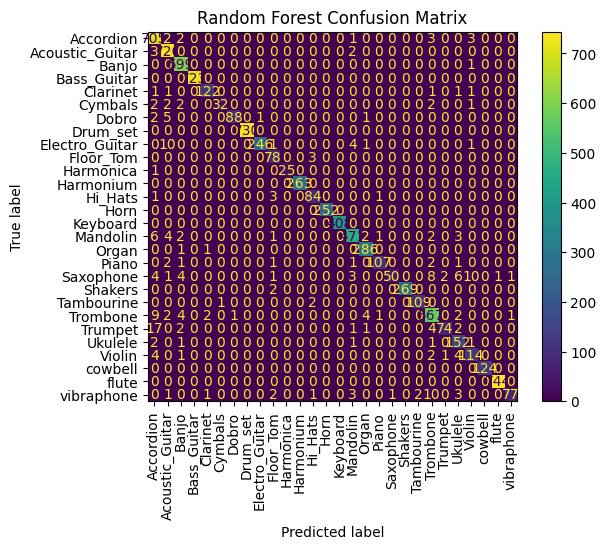

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(16,14))
disp = ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test, display_labels=le.classes_, xticks_rotation='vertical'
)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [24]:
import joblib

joblib.dump(rf, "instrument_classifier_random_forest.pkl")
joblib.dump(le, "label_encoder.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and label encoder saved successfully!")

Model and label encoder saved successfully!


In [25]:
rf = joblib.load("instrument_classifier_random_forest.pkl")
le = joblib.load("label_encoder.pkl")
scaler = joblib.load("scaler.pkl")

In [26]:
def extract_features_for_prediction(file_path):
    # Load audio (same setting as training)
    audio, sr = librosa.load(file_path, sr=22050, duration=5.0, mono=True)

    # ---- 1. MFCC (20) ----
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)
    mfcc_mean = np.mean(mfcc.T, axis=0)   # (20,)

    # ---- 2. Chroma (12) ----
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    chroma_mean = np.mean(chroma.T, axis=0)  # (12,)

    # ---- 3. Spectral Centroid (1) ----
    centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))

    # ---- 4. Spectral Bandwidth (1) ----
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))

    # ---- 5. Spectral Rolloff (1) ----
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr))

    # ---- 6. Zero Crossing Rate (1) ----
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=audio))

    # ---- Combine All into ONE Feature Vector ----
    features = np.hstack([
        mfcc_mean,       # 20
        chroma_mean,     # 12
        centroid,        # 1
        bandwidth,       # 1
        rolloff,         # 1
        zcr              # 1
    ])

    return features    # TOTAL = 36 FEATURES

In [27]:
import joblib
import librosa
import numpy as np

In [28]:
import os

print("Files in current directory:")
for f in os.listdir():
    print(f)

Files in current directory:
.config
kaggle.json
label_encoder.pkl
scaler.pkl
music-instrunment-sounds-for-classification.zip
instrument_classifier_random_forest.pkl
dataset
features_dataset.csv
sample_data


In [29]:
import pandas as pd
import joblib

# Load dataset
df = pd.read_csv("features_dataset.csv")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# Split features and labels
X = df.drop("label", axis=1)
y = df["label"]

# Load saved label encoder
le = joblib.load("label_encoder.pkl")

# Encode labels
y = le.transform(y)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Dataset shape: (42311, 37)
Columns: ['mfcc_0', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'mfcc_14', 'mfcc_15', 'mfcc_16', 'mfcc_17', 'mfcc_18', 'mfcc_19', 'chroma_0', 'chroma_1', 'chroma_2', 'chroma_3', 'chroma_4', 'chroma_5', 'chroma_6', 'chroma_7', 'chroma_8', 'chroma_9', 'chroma_10', 'chroma_11', 'centroid', 'bandwidth', 'rolloff', 'zcr', 'label']
Feature matrix shape: (42311, 36)
Labels shape: (42311,)


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed.")

Train shape: (33848, 36)
Test shape: (8463, 36)
Scaling completed.


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train Logistic Regression
lr = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial",
    n_jobs=-1
)

lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluate
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.8961361219425735
                 precision    recall  f1-score   support

      Accordion       0.76      0.82      0.79       716
Acoustic_Guitar       0.88      0.88      0.88       731
          Banjo       0.85      0.87      0.86       600
    Bass_Guitar       0.99      1.00      1.00       723
       Clarinet       0.83      0.91      0.87       127
        Cymbals       0.73      0.54      0.62        41
          Dobro       0.88      0.89      0.88        97
       Drum_set       1.00      1.00      1.00       730
 Electro_Guitar       0.88      0.83      0.85       263
      Floor_Tom       0.75      0.80      0.77        81
      Harmonica       0.90      0.69      0.78        26
      Harmonium       1.00      1.00      1.00       263
        Hi_Hats       0.83      0.76      0.80        89
           Horn       1.00      1.00      1.00       252
       Keyboard       1.00      1.00      1.00       408
       Mandolin       0.72      0.73  

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

n_estimators_list = list(range(100, 1100, 100))
rf_accuracies = []

for n in n_estimators_list:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    rf_temp.fit(X_train, y_train)
    y_pred = rf_temp.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    rf_accuracies.append(acc)

    print(f"n_estimators = {n}, Accuracy = {acc:.4f}")

n_estimators = 100, Accuracy = 0.9698
n_estimators = 200, Accuracy = 0.9719
n_estimators = 300, Accuracy = 0.9718
n_estimators = 400, Accuracy = 0.9732
n_estimators = 500, Accuracy = 0.9734
n_estimators = 600, Accuracy = 0.9728
n_estimators = 700, Accuracy = 0.9729
n_estimators = 800, Accuracy = 0.9727
n_estimators = 900, Accuracy = 0.9734
n_estimators = 1000, Accuracy = 0.9734


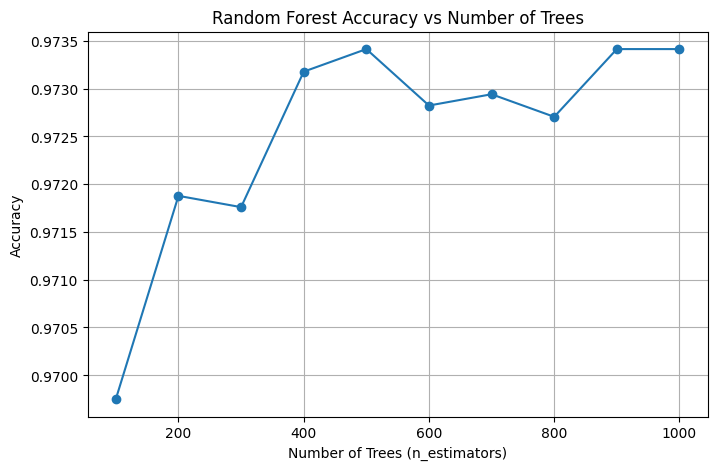

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, rf_accuracies, marker='o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.grid(True)
plt.show()

In [34]:
from sklearn.ensemble import RandomForestClassifier
import joblib

rf_final = RandomForestClassifier(
    n_estimators=700,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

joblib.dump(rf_final, "final_random_forest_model.pkl")

['final_random_forest_model.pkl']

In [35]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

degrees = list(range(3, 11))
svm_poly_accuracies = []

for d in degrees:
    svm_poly = SVC(
        kernel="poly",
        degree=d,
        C=1.0
    )

    svm_poly.fit(X_train, y_train)
    y_pred = svm_poly.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    svm_poly_accuracies.append(acc)

    print(f"Polynomial Degree = {d}, Accuracy = {acc:.4f}")

Polynomial Degree = 3, Accuracy = 0.9386
Polynomial Degree = 4, Accuracy = 0.8582
Polynomial Degree = 5, Accuracy = 0.7822
Polynomial Degree = 6, Accuracy = 0.7240
Polynomial Degree = 7, Accuracy = 0.6769
Polynomial Degree = 8, Accuracy = 0.6402
Polynomial Degree = 9, Accuracy = 0.6135
Polynomial Degree = 10, Accuracy = 0.5966


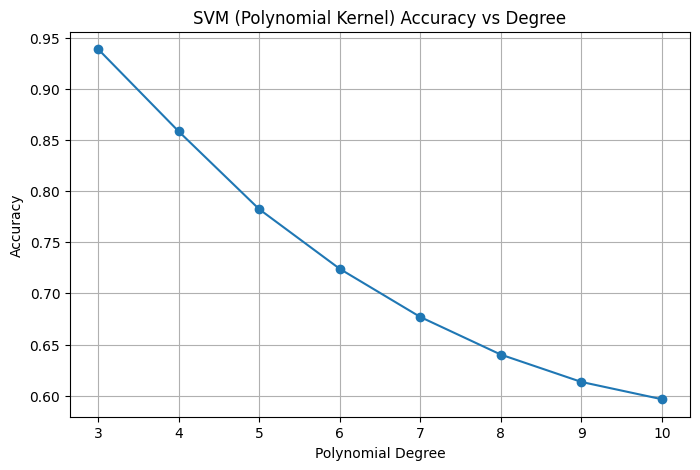

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(degrees, svm_poly_accuracies, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("Accuracy")
plt.title("SVM (Polynomial Kernel) Accuracy vs Degree")
plt.grid(True)
plt.show()

In [37]:
svm_poly_final = SVC(
    kernel="poly",
    degree=3,
    C=1.0
)

svm_poly_final.fit(X_train, y_train)

SVC(kernel='poly')

In [38]:
import joblib
joblib.dump(svm_poly_final, "svm_poly_final.pkl")

['svm_poly_final.pkl']

In [39]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

gamma_values = np.arange(0.1, 1.1, 0.1)
svm_rbf_accuracies = []

for g in gamma_values:
    svm_rbf = SVC(
        kernel="rbf",
        gamma=g
    )

    svm_rbf.fit(X_train, y_train)
    y_pred = svm_rbf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    svm_rbf_accuracies.append(acc)

    print(f"gamma = {g:.1f}, Accuracy = {acc:.4f}")

gamma = 0.1, Accuracy = 0.9823
gamma = 0.2, Accuracy = 0.9622
gamma = 0.3, Accuracy = 0.9287
gamma = 0.4, Accuracy = 0.8965
gamma = 0.5, Accuracy = 0.8583
gamma = 0.6, Accuracy = 0.8277
gamma = 0.7, Accuracy = 0.8043
gamma = 0.8, Accuracy = 0.7860
gamma = 0.9, Accuracy = 0.7725
gamma = 1.0, Accuracy = 0.7590


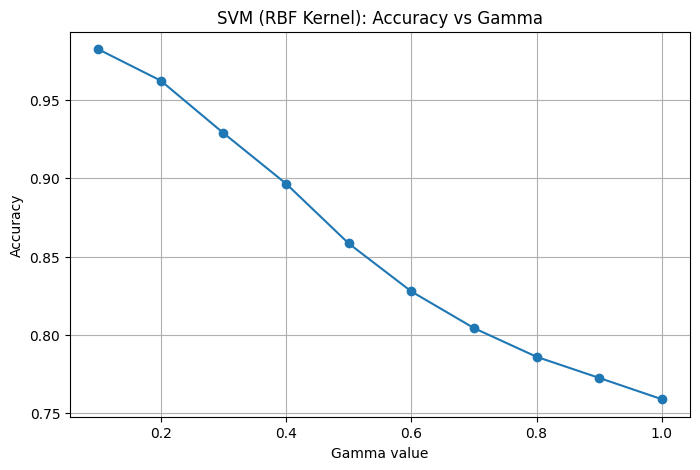

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(gamma_values, svm_rbf_accuracies, marker='o')
plt.xlabel("Gamma value")
plt.ylabel("Accuracy")
plt.title("SVM (RBF Kernel): Accuracy vs Gamma")
plt.grid(True)
plt.show()

In [41]:
svm_rbf_final = SVC(
    kernel="rbf",
    gamma=0.2
)

svm_rbf_final.fit(X_train, y_train)

SVC(gamma=0.2)

In [42]:
import joblib

joblib.dump(svm_rbf_final, "final_svm_rbf_model.pkl")

['final_svm_rbf_model.pkl']

In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1] + list(range(5, 101, 5))
knn_accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)

    y_pred = knn_temp.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    knn_accuracies.append(acc)

    print(f"k = {k}, Accuracy = {acc:.4f}")

k = 1, Accuracy = 0.9804
k = 5, Accuracy = 0.9615
k = 10, Accuracy = 0.9518
k = 15, Accuracy = 0.9428
k = 20, Accuracy = 0.9369
k = 25, Accuracy = 0.9316
k = 30, Accuracy = 0.9250
k = 35, Accuracy = 0.9195
k = 40, Accuracy = 0.9139
k = 45, Accuracy = 0.9097
k = 50, Accuracy = 0.9056
k = 55, Accuracy = 0.9017
k = 60, Accuracy = 0.8966
k = 65, Accuracy = 0.8919
k = 70, Accuracy = 0.8872
k = 75, Accuracy = 0.8825
k = 80, Accuracy = 0.8796
k = 85, Accuracy = 0.8763
k = 90, Accuracy = 0.8725
k = 95, Accuracy = 0.8700
k = 100, Accuracy = 0.8658


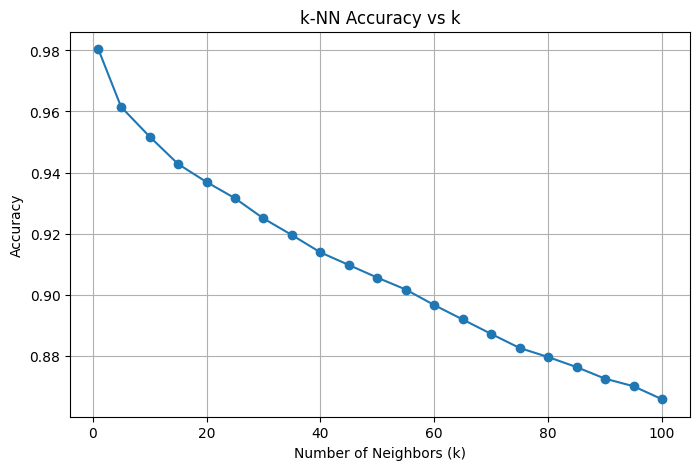

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(k_values, knn_accuracies, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("k-NN Accuracy vs k")
plt.grid(True)
plt.show()

In [45]:
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train, y_train)

KNeighborsClassifier()

In [46]:
from sklearn.metrics import classification_report

y_pred_knn = knn_final.predict(X_test)

print("k-NN Accuracy (k=5):", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

k-NN Accuracy (k=5): 0.9614793808342196
                 precision    recall  f1-score   support

      Accordion       0.93      0.98      0.96       716
Acoustic_Guitar       0.97      1.00      0.98       731
          Banjo       0.92      1.00      0.96       600
    Bass_Guitar       0.99      1.00      1.00       723
       Clarinet       0.93      0.91      0.92       127
        Cymbals       1.00      0.88      0.94        41
          Dobro       0.90      0.96      0.93        97
       Drum_set       1.00      1.00      1.00       730
 Electro_Guitar       0.99      0.90      0.94       263
      Floor_Tom       0.78      0.96      0.86        81
      Harmonica       0.96      0.92      0.94        26
      Harmonium       1.00      1.00      1.00       263
        Hi_Hats       0.85      0.88      0.86        89
           Horn       1.00      1.00      1.00       252
       Keyboard       0.98      1.00      0.99       408
       Mandolin       0.96      0.96      0.96 

In [47]:
import joblib
joblib.dump(knn_final, "knn_k5_model.pkl")

['knn_k5_model.pkl']

In [48]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

Naive Bayes Accuracy: 0.7783291976840364
                 precision    recall  f1-score   support

      Accordion       0.66      0.62      0.64       716
Acoustic_Guitar       0.83      0.72      0.77       731
          Banjo       0.69      0.59      0.64       600
    Bass_Guitar       1.00      0.99      0.99       723
       Clarinet       0.61      0.57      0.59       127
        Cymbals       0.25      0.46      0.32        41
          Dobro       0.41      0.81      0.55        97
       Drum_set       1.00      0.99      1.00       730
 Electro_Guitar       0.67      0.62      0.64       263
      Floor_Tom       0.37      0.77      0.50        81
      Harmonica       0.65      0.77      0.70        26
      Harmonium       1.00      1.00      1.00       263
        Hi_Hats       0.50      0.73      0.59        89
           Horn       1.00      0.92      0.96       252
       Keyboard       1.00      0.94      0.97       408
       Mandolin       0.60      0.48      0.53

In [49]:
from sklearn.metrics import accuracy_score
import pandas as pd

model_names = []
accuracies = []

# Logistic Regression
model_names.append("Logistic Regression")
accuracies.append(accuracy_score(y_test, lr.predict(X_test)))

# Random Forest
model_names.append("Random Forest")
accuracies.append(accuracy_score(y_test, rf_final.predict(X_test)))

# SVM Polynomial
model_names.append("SVM (Polynomial)")
accuracies.append(accuracy_score(y_test, svm_poly.predict(X_test)))

# SVM RBF
model_names.append("SVM (RBF)")
accuracies.append(accuracy_score(y_test, svm_rbf.predict(X_test)))

# k-NN
model_names.append("k-NN")
accuracies.append(accuracy_score(y_test, knn_temp.predict(X_test)))

# Naive Bayes
model_names.append("Naive Bayes")
accuracies.append(accuracy_score(y_test, nb.predict(X_test)))

# Create comparison table
results_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

results_df

,Model,Accuracy
0,Logistic Regression,0.896136
1,Random Forest,0.972941
2,SVM (Polynomial),0.596597
3,SVM (RBF),0.758951
4,k-NN,0.865769
5,Naive Bayes,0.778329


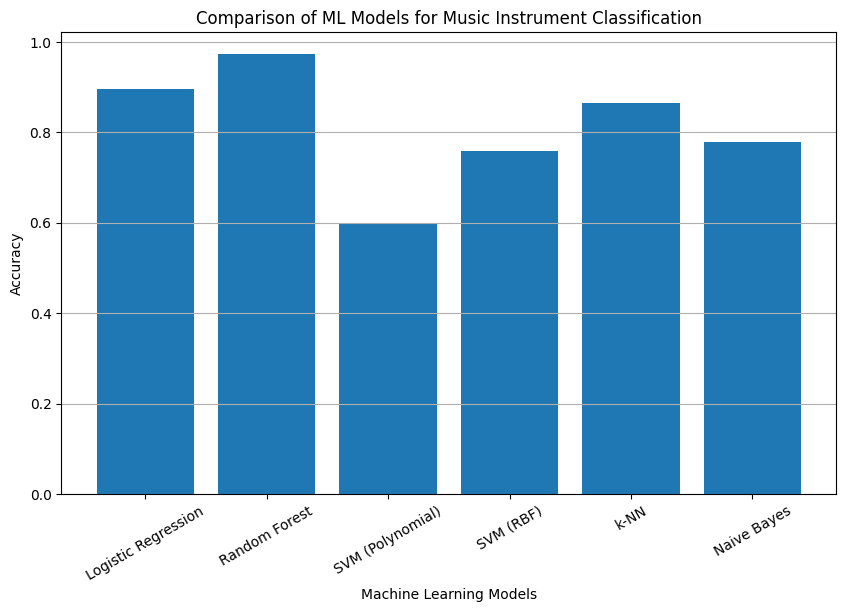

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(model_names, accuracies)
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.title("Comparison of ML Models for Music Instrument Classification")
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.show()

In [51]:
import librosa
import numpy as np

def extract_features(file_path):
    audio, sr = librosa.load(file_path, sr=22050, duration=5.0, mono=True)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)
    mfcc_mean = np.mean(mfcc.T, axis=0)

    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    chroma_mean = np.mean(chroma.T, axis=0)

    centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=audio))

    features = np.hstack([
        mfcc_mean,
        chroma_mean,
        centroid,
        bandwidth,
        rolloff,
        zcr
    ])

    return features

In [52]:
from google.colab import files

print("Please upload your audio file (e.g., in .wav format):")
uploaded = files.upload()

# Get the name of the uploaded file
if uploaded:
    uploaded_file_name = list(uploaded.keys())[0]
    print(f"Uploaded file: {uploaded_file_name}")
else:
    uploaded_file_name = None

Please upload your audio file (e.g., in .wav format):


Saving Spring-Flowers(chosic.com).mp3 to Spring-Flowers(chosic.com).mp3
Uploaded file: Spring-Flowers(chosic.com).mp3


In [53]:
if uploaded_file_name:
    # Extract features from the uploaded audio file
    new_audio_features = extract_features(uploaded_file_name)

    # Scale the features using the trained scaler
    new_audio_features_scaled = scaler.transform([new_audio_features])

    # Make prediction
    prediction_encoded = rf_final.predict(new_audio_features_scaled)

    # Decode the prediction to get the instrument name
    predicted_instrument = le.inverse_transform(prediction_encoded)

    print(f"The predicted instrument is: {predicted_instrument[0]}")
else:
    print("No file was uploaded. Please upload an audio file to make a prediction.")

The predicted instrument is: Piano


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
